In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
sentiment = pd.read_csv("../data/fear_greed_index.csv")
trades = pd.read_csv("../data/historical_data.csv")

print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)

Sentiment shape: (2644, 4)
Trades shape: (211224, 16)


In [ ]:
sentiment.columns, trades.columns

In [3]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
# Convert date
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['Date'] = sentiment['date'].dt.date

# Simplify sentiment
def simplify(x):
    return 'Fear' if 'Fear' in x else 'Greed'

sentiment['sentiment'] = sentiment['classification'].apply(simplify)

# Keep only required columns
sentiment = sentiment[['Date', 'sentiment']]

sentiment.head()

,Date,sentiment
0,2018-02-01,Fear
1,2018-02-02,Fear
2,2018-02-03,Fear
3,2018-02-04,Fear
4,2018-02-05,Fear


In [6]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)
trades['Date'] = trades['Timestamp IST'].dt.date

In [ ]:
trades.head()


In [7]:
# Rename columns
trades = trades.rename(columns={
    'Account': 'account',
    'Execution Price': 'execution_price',
    'Size Tokens': 'size_tokens',
    'Size USD': 'size_usd',
    'Side': 'side',
    'Closed PnL': 'closedPnL',
    'Fee': 'fee'
})

In [8]:
df = trades.merge(sentiment, on='Date', how='left')
df['sentiment'].isnull().sum()

np.int64(6)

In [9]:
df['win'] = df['closedPnL'] > 0


In [10]:
df.groupby('sentiment')['closedPnL'].describe()

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
Fear,83237.0,49.212077,990.875398,-35681.74723,0.0,0.0,5.607450,135329.09010
Greed,127981.0,48.118246,867.308701,-117990.10410,0.0,0.0,5.907704,74530.52371


In [11]:
df.groupby('sentiment')['win'].mean()


sentiment
Fear     0.407871
Greed    0.413444
Name: win, dtype: float64

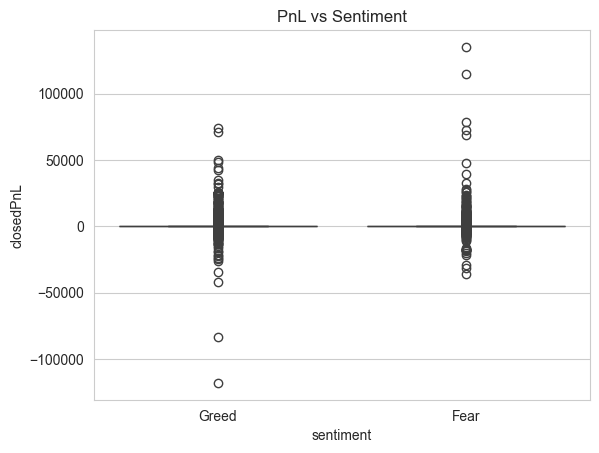

In [12]:
sns.boxplot(x='sentiment', y='closedPnL', data=df)
plt.title("PnL vs Sentiment")
plt.show()

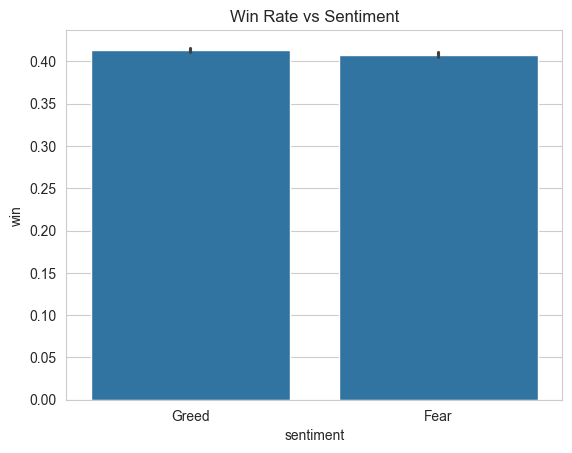

In [13]:
sns.barplot(x='sentiment', y='win', data=df)
plt.title("Win Rate vs Sentiment")
plt.show()

In [14]:
df.groupby('sentiment')['size_usd'].mean()

sentiment
Fear     7182.011019
Greed    4635.764077
Name: size_usd, dtype: float64

In [15]:
df.groupby('sentiment').size()

sentiment
Fear      83237
Greed    127981
dtype: int64

In [16]:
df.groupby('sentiment')['closedPnL'].std()

sentiment
Fear     990.875398
Greed    867.308701
Name: closedPnL, dtype: float64

In [ ]:
median_size = df['size_usd'].median()

df['size_group'] = df['size_usd'].apply(
    lambda x: 'High' if x > median_size else 'Low'
)

df.groupby(['size_group', 'sentiment'])['closedPnL'].mean()

In [18]:
# PnL distribution
pnl_stats = df.groupby('sentiment')['closedPnL'].describe()

# Win rate
win_rate = df.groupby('sentiment')['win'].mean()

# Drawdown proxy (use lower tail / min)
drawdown = df.groupby('sentiment')['closedPnL'].min()

pnl_stats, win_rate, drawdown

(              count       mean         std           min  25%  50%       75%  \
 sentiment                                                                      
 Fear        83237.0  49.212077  990.875398  -35681.74723  0.0  0.0  5.607450   
 Greed      127981.0  48.118246  867.308701 -117990.10410  0.0  0.0  5.907704   
 
                     max  
 sentiment                
 Fear       135329.09010  
 Greed       74530.52371  ,
 sentiment
 Fear     0.407871
 Greed    0.413444
 Name: win, dtype: float64,
 sentiment
 Fear     -35681.74723
 Greed   -117990.10410
 Name: closedPnL, dtype: float64)

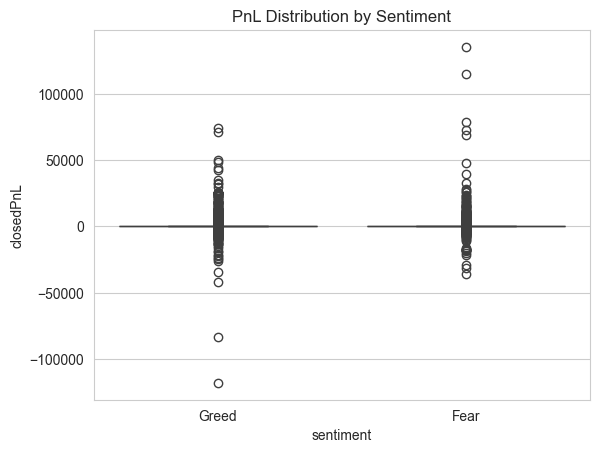

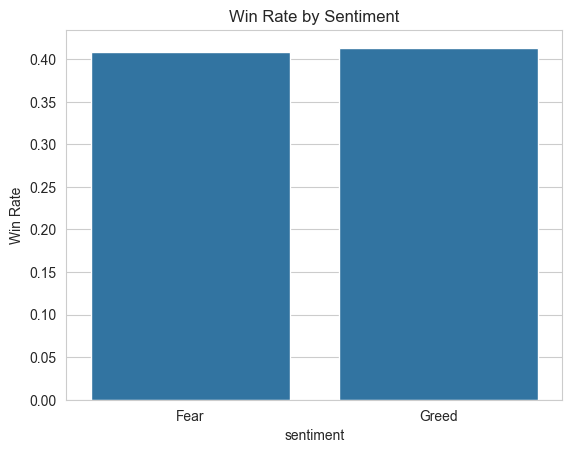

In [19]:
# Visuals
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x='sentiment', y='closedPnL', data=df)
plt.title("PnL Distribution by Sentiment")
plt.show()

sns.barplot(x=win_rate.index, y=win_rate.values)
plt.title("Win Rate by Sentiment")
plt.ylabel("Win Rate")
plt.show()

In [29]:
# Position size (risk proxy)
size_mean = df.groupby('sentiment')['size_usd'].mean()

# Trade frequency
trade_count = df.groupby('sentiment').size()

# Volatility
volatility = df.groupby('sentiment')['closedPnL'].std()

size_mean, trade_count, volatility

(sentiment
 Fear     7182.011019
 Greed    4635.764077
 Name: size_usd, dtype: float64,
 sentiment
 Fear      83237
 Greed    127981
 dtype: int64,
 sentiment
 Fear     990.875398
 Greed    867.308701
 Name: closedPnL, dtype: float64)

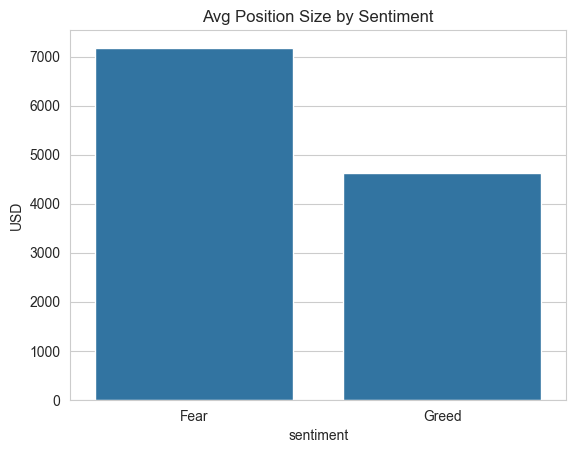

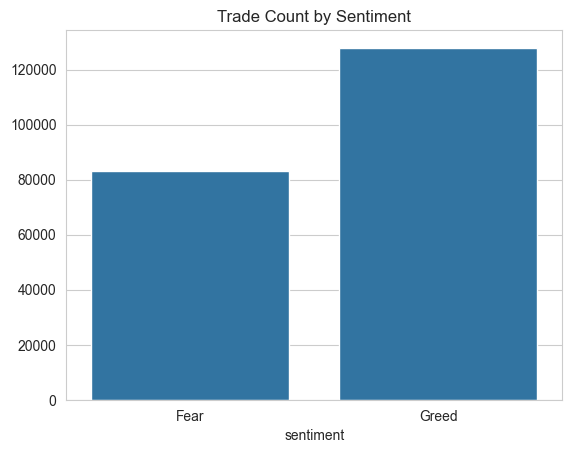

In [30]:
# Charts
sns.barplot(x=size_mean.index, y=size_mean.values)
plt.title("Avg Position Size by Sentiment")
plt.ylabel("USD")
plt.show()

sns.barplot(x=trade_count.index, y=trade_count.values)
plt.title("Trade Count by Sentiment")
plt.show()

In [31]:
counts = df['account'].value_counts()
freq_accounts = counts[counts > counts.median()].index

df['freq_group'] = df['account'].apply(lambda x: 'Frequent' if x in freq_accounts else 'Infrequent')

df.groupby(['freq_group', 'sentiment'])['closedPnL'].mean()

freq_group  sentiment
Frequent    Fear          47.325875
            Greed         39.431386
Infrequent  Fear          61.968833
            Greed        121.546240
Name: closedPnL, dtype: float64

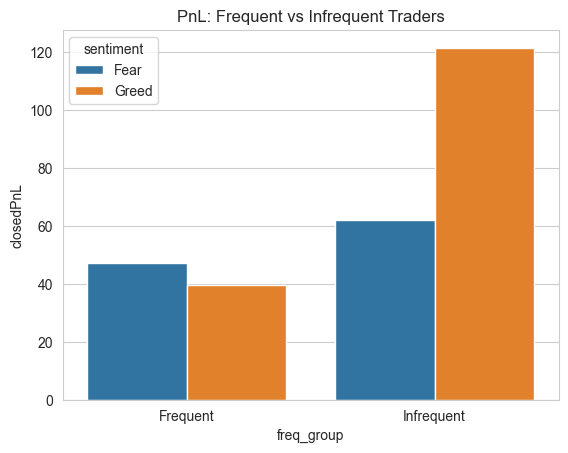

In [32]:
seg1 = df.groupby(['freq_group', 'sentiment'])['closedPnL'].mean().reset_index()

sns.barplot(x='freq_group', y='closedPnL', hue='sentiment', data=seg1)
plt.title("PnL: Frequent vs Infrequent Traders")
plt.show()

In [33]:
total_pnl = df.groupby('account')['closedPnL'].sum()
winners = total_pnl[total_pnl > 0].index

df['trader_type'] = df['account'].apply(lambda x: 'Winner' if x in winners else 'Loser')

df.groupby(['trader_type', 'sentiment'])['closedPnL'].mean()

trader_type  sentiment
Loser        Fear          30.149398
             Greed       -102.166075
Winner       Fear          50.453180
             Greed         53.138483
Name: closedPnL, dtype: float64

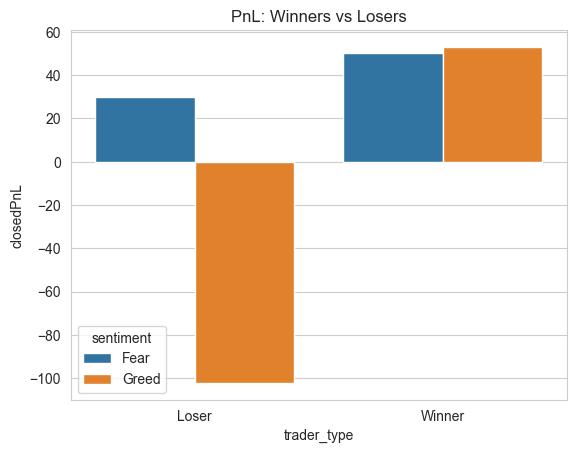

In [34]:
seg2 = df.groupby(['trader_type', 'sentiment'])['closedPnL'].mean().reset_index()

sns.barplot(x='trader_type', y='closedPnL', hue='sentiment', data=seg2)
plt.title("PnL: Winners vs Losers")
plt.show()

In [35]:
median_size = df['size_usd'].median()

df['size_group'] = df['size_usd'].apply(lambda x: 'High' if x > median_size else 'Low')

df.groupby(['size_group', 'sentiment'])['closedPnL'].mean()

size_group  sentiment
High        Fear         87.647166
            Greed        96.552173
Low         Fear          2.971356
            Greed         5.166153
Name: closedPnL, dtype: float64

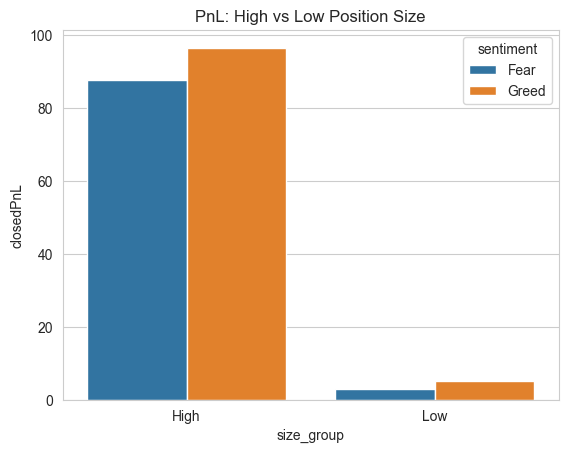

In [36]:
seg3 = df.groupby(['size_group', 'sentiment'])['closedPnL'].mean().reset_index()

sns.barplot(x='size_group', y='closedPnL', hue='sentiment', data=seg3)
plt.title("PnL: High vs Low Position Size")
plt.show()

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Create label: profitable trade
df['profit_label'] = (df['closedPnL'] > 0).astype(int)

# Encode sentiment
df['sentiment_enc'] = df['sentiment'].map({'Fear': 0, 'Greed': 1})

features = ['size_usd', 'sentiment_enc']
X = df[features]
y = df['profit_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.6071961178837733


In [24]:
# Daily aggregates per trader
daily = df.groupby(['account', 'Date']).agg({
    'closedPnL': 'sum',
    'size_usd': 'mean',
    'win': 'mean'
}).reset_index()

sent_map = df[['Date', 'sentiment']].drop_duplicates()
daily = daily.merge(sent_map, on='Date', how='left')

# Encode sentiment
daily['sentiment_enc'] = daily['sentiment'].map({'Fear': 0, 'Greed': 1})

daily.head()

,account,Date,closedPnL,size_usd,win,sentiment,sentiment_enc
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,5089.718249,0.000000,Greed,1.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,7976.664412,0.000000,Greed,1.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,23734.500000,0.000000,Greed,1.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,28186.666667,0.000000,Greed,1.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,17248.148148,0.444444,Greed,1.0


In [25]:
# Next-day PnL
daily['next_pnl'] = daily.groupby('account')['closedPnL'].shift(-1)

# Bucket: 1 = profitable next day, 0 = not
daily['next_profit_label'] = (daily['next_pnl'] > 0).astype(int)

In [26]:
# Absolute change as a simple volatility proxy
daily['pnl_volatility'] = daily.groupby('account')['closedPnL'].diff().abs()

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

features = ['closedPnL', 'size_usd', 'win', 'sentiment_enc']
data = daily.dropna(subset=features + ['next_profit_label'])

X = data[features]
y = data['next_profit_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.6303418803418803


In [ ]:
from sklearn.ensemble import RandomForestRegressor

data_reg = daily.dropna(subset=features + ['pnl_volatility'])

X = data_reg[features]
y = data_reg['pnl_volatility']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

reg = RandomForestRegressor()
reg.fit(X_train, y_train)

print("R2 Score:", reg.score(X_test, y_test))

In [ ]:
df.to_csv("../data/merged.csv", index=False)